### Individual Planning Report

Vicky N _ Individual Planning Report _ 11 / 12 / 2025

In [126]:
library(repr)
library(tidyverse)
library(tidymodels)
library(RColorBrewer)

In [127]:
# Loading in Players Data 
players_url <- ("https://raw.githubusercontent.com/vicky-nak/Individual-Planning-Report/refs/heads/main/Individual%20Planning%20Report/players.csv")
players <- read_csv(players_url)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


**Data Description** _Breakdown of minecraft server player data_

##### Players data 

###### DATA COLLECTION 
A minecreaft server was set up by a research group at UBC to record how people play video games. Variables such as name and gender are input by the user while variables like played hours are calculated by the game. This dataset contains 196 observations and 7 variables. 

###### DATA SUMMARY

In [128]:
# Experience summary
Pros      <- players |> filter(experience == "Pro")      |> nrow()
Amateurs  <- players |> filter(experience == "Amateur")  |> nrow()
Beginners <- players |> filter(experience == "Beginner") |> nrow() 
Veterans  <- players |> filter(experience == "Veteran")  |> nrow()
Regulars  <- players |> filter(experience == "Regular")  |> nrow()
# Subscribe summary
Subscribed    <- players |> filter(subscribe == "TRUE")  |> nrow()
Not_subcribed <- players |> filter(subscribe == "FALSE") |> nrow() 
# Played hours summary
Mean_played_hours <- players |> filter(!is.na(played_hours)) |> summarize(mean(played_hours)) |>  as.numeric()
Unplaying_players <- players |> filter(!is.na(played_hours)) |> filter(played_hours == 0) |> nrow()
# Gender summary
Males             <- players |> filter(gender == "Male")              |> nrow()
Females           <- players |> filter(gender == "Female")            |> nrow() 
Two_spirited      <- players |> filter(gender == "Two-Spirited")      |> nrow() 
Non_binary        <- players |> filter(gender == "Non-binary")        |> nrow() 
Agender           <- players |> filter(gender == "Agender")           |> nrow()
Other             <- players |> filter(gender == "Other")             |> nrow() 
Prefer_not_to_say <- players |> filter(gender == "Prefer not to say") |> nrow() 
# Age summary
Mean_age   <- players |> filter(!is.na(Age), na.rm = TRUE) |> summarize(mean(Age)) |> as.numeric()
Median_age <- players |> filter(!is.na(Age), na.rm = TRUE) |> summarize(median(Age)) |> as.numeric()

# Player Data summary
Experience_summary <- c(Pros, Amateurs, Beginners, Veterans, Regulars) |> print()
Subscribe_summary <- c(Subscribed, Not_subcribed) |> print()
Played_hours_summary <- c(Mean_played_hours, Unplaying_players) |> print()
Gender_summary <- c(Males, Females, Two_spirited, Non_binary, Agender, Other, Prefer_not_to_say) |> print()
Age_summary <- c(Mean_age, Median_age) |> print()

[1] 14 63 35 48 36
[1] 144  52
[1]  5.845918 85.000000
[1] 124  37   6  15   2   1  11
[1] 21.13918 19.00000


###### VARIABLE ANALYSIS

| Variable       | Type      | Description w/ examples                                                    | Issues / Changes               | Statistics / Observations
| -------------- | --------- | -------------------------------------------------------------------------- | ------------------------------ | --------------------------------------------------------------------
| `experience`   | character | A players level of knowledge on the game                                   | character -> factor            | `Amateur = 63` `Beginner = 35` `Pro = 14` `Veteran = 48` `Regular = 36`
| `subscribe`    | logical   | Whether a player is subscribed to the newsletter `TRUE` or `FALSE`         | subscribe -> `subscribed`      | `Subscribed = 144` `Not subcribed = 52`
| `hashedEmail`  | character | Encrypted email, a collection of numbers and lower case letters            | hashedEmail -> `hashed_email`  | 
| `played_hours` | double    | Hours of game time logged as a double to one decimal place                 |                                | `Mean played hours = 5.85` `Unplaying players = 85`
| `name`         | character | A players name, may have duplicates that do not represent the same player  |                                | 
| `gender`       | character | The gender of the player                                                   | character -> factor            | `Males = 124` `Females = 37` `Two-spirited = 6` `Non-binary = 15` `Agender = 2` `Other = 1` `Prefer not to say = 11`
| `Age`          | double    | Age of player (integer)                                                           | double -> integer, Age -> `age` | `Mean age = 21.14` `Median age = 19`


###### POTENTIAL ISSUES
Aside from naming and data type changes mentioned in the variable analysis table, any N/A values would need to be delt with such as the age in the last observation. If there are any duplicates in the names then they are not useful as identifiers and we must rely on the `hashedEmail`.



**Questions**

###### RESEARCH QUESTION
I will be addressing which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts. Summarizing the dataset revelaed around 43% of players never play. According to Plaicraft rules, each new player recieves 30 minutes of time they are allowed to play alone without interacting with others. Making 30 minutes a substantial amount of data for the research. Therefore, I want to find out: **_Does a player's experience, age, and gender predict where a player would log more than half an hour on the game?_** This question requires played_hours to be mutated into a logical variable of players that played more than 0.5 hours. Given I would be predicting a categorical (logical) variable, I would most likely use knn classification.

**Exploratory Data Analysis and Visualization**
_Demonstrate that the dataset can be loaded into R.
Do the minimum necessary wrangling to turn your data into a tidy format. Do not do any additional wrangling here; that will happen later during the group project phase.
Compute the mean value for each quantitative variable in the players.csv data set. Report the mean values in a table format.
Make a few exploratory visualizations of the data to help you understand it.
Use our visualization best practices to make high-quality plots (make sure to include labels, titles, units of measurement, etc)
Explain any insights you gain from these plots that are relevant to address your question
Note: do not perform any predictive analysis here. We are asking for an exploration of the relevant variables to demonstrate that you understand them well before performing any additional modelling, and to identify potential problems you anticipate encountering._

In [129]:
# Loading in the players dataset was done at the beginning of the file
slice(players, 1:3)

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17


###### TIDY DATA
The data for players is already tidy as it meets the three criteria for tidy data. Each row didrepresent a single obervation or player in this case. Each column was a single variable, and while some data types could be changes, the columns were tidy nonetheless. Lastly, the values in each cell were singular and representatitve of one value only.

###### MEAN VALUES

In [130]:
means_of_quantitative_variables <- players |>
    select(played_hours, Age) |>
    summarize(mean_played_hours = mean(played_hours), mean_age = mean(Age, na.rm = TRUE))
means_of_quantitative_variables

mean_played_hours,mean_age
<dbl>,<dbl>
5.845918,21.13918


###### EXPLORATORY VISUALIZATION

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


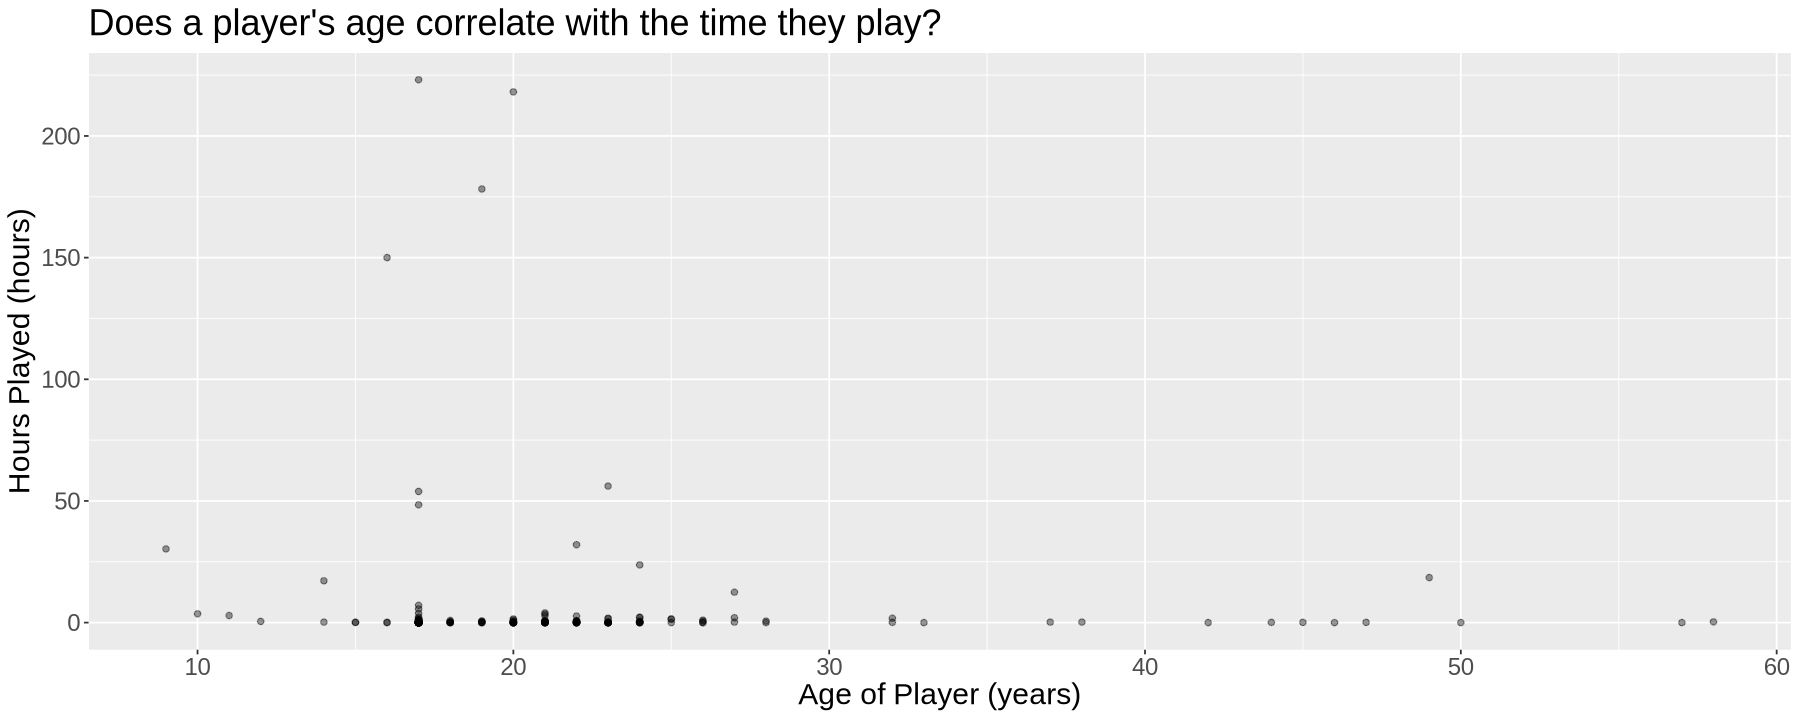

In [153]:
# A scatterplot showing the relationship between age and hours players
options(repr.plot.width = 15, repr.plot.height = 6)
age_vs_played_hours <- players |>
    ggplot(aes(x = Age, y = played_hours)) +
           geom_point(alpha = 0.4) +
           labs(x = "Age of Player (years)", y = "Hours Played (hours)") +
           theme(text = element_text(size = 18)) +
           ggtitle("Does a player's age correlate with the time they play?")
age_vs_played_hours

###### Does a player's age correlate with the time they play?  |  age_vs_played_hours analysis
This graph does not tell us much given the extremes between the hours players played. We can tell that ges 10 to 25 are more likely to log higher hours than ages 30+. Given the outliers, as our research question states, categorizing the hours played may be very helpful. The best way I can think to do that in a visualisation is a histogram. 

**Methods and Plan**
_Propose one method to address your question of interest using the selected dataset and explain why it was chosen. Do not perform any modelling or present results at this stage. We are looking for high-level planning regarding model choice and justifying that choice.
In your explanation, respond to the following questions:
Why is this method appropriate?
Which assumptions are required, if any, to apply the method selected?
What are the potential limitations or weaknesses of the method selected?
How are you going to compare and select the model?
How are you going to process the data to apply the model? For example: Are you splitting the data? How? How many splits? What proportions will you use for the splits? At what stage will you split? Will there be a validation set? Will you use cross validation?_